# K-means clustering segmentation

## Understanding a little bit of Open CV in k-means clustering documentation:

### Learning how to use cv2.kmeans()

Input parameters:

- samples: It should be of np.float32 data type, and each feature should be put in a single column.
- nclusters(K): number of clusters required at end
- criteria: It is the iteration termination criteria. When this criteria is satisfied, algorithm iteration stops. Actually, it should be a tuple of 3 parameters. They are (type, max_iter, epsilon):
    - type of termination criteria:
        - cv2.TERM_CRITERIA_EPS: stop the algorithm iteration if specficied accuracy, epsilon, is reached
        - cv2.TERM_CRITERIA_MAX_ITER: stop the algorithm after que specified number of iterations, max_iter
        - cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER: stop the iteration when any of the above conditions is met.
    - max_iter: an integer specifying maximum number of iterations.
    - epsilon: required accuracy
- attempts: flag to specify the number of times the algorithm is executed using different initial labellings. the algorithm returns the labels that yield the best compactness. This compactness is returned as output.
- flags: this flag is used to specify how initial center are taken. Normally two flags are used for this: cv2.KMEANS_PP_CENTERS and cv2.KMEANS_RANDOM_CENTERS.

Output parameters:

1) Compactness: It is the sum of squared distance from each point to their corresponding center.
2) Labels: This is the label array (same as 'code' in previous article) where each element marked '0', '1', ...
3) Centers: This is array of centers of clusters.


https://docs.opencv.org/4.x/d1/d5c/tutorial_py_kmeans_opencv.html

In [ ]:
import numpy as np
import cv2

img = cv2.imread('image.jpg')
img2 = img.reshape((-1,3))    # Reshaping: -1 unite the first two RGB positions 

In [2]:
img2

array([[133, 178, 252],
       [132, 177, 251],
       [131, 176, 250],
       ...,
       [  0,   0,  17],
       [  0,   0,   9],
       [  6,   0,   5]], shape=(40911071, 3), dtype=uint8)

In [3]:
img2 = np.float32(img2)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 50, 1.0)

In [4]:
# Clusters
k=5
attempts = 20

compactness,label,center = cv2.kmeans(img2, k, None, criteria, attempts, cv2.KMEANS_PP_CENTERS)

In [5]:
# Converting back to into uint8 and making original image
center = np.uint8(center)
res = center[label.flatten()]

In [6]:
res2 = res.reshape((img.shape))
print(label)

[[2]
 [2]
 [2]
 ...
 [1]
 [1]
 [1]]


In [7]:
cv2.imwrite('k_means_segmented_images/SN100CVE-1_500x.jpg', res2)

True

In [ ]:
print(center)

counts = np.bincount(label.flatten())

total_pixels = len(label.flatten())

percentages = (counts/total_pixels)*100

print(percentages)

[[244 248 249]
 [164 165 169]
 [ 69  59  60]
 [202 212 216]
 [166 190 190]]
[27.51709163  5.30865165  1.14980201 17.17783397 48.84662074]


In [23]:
import matplotlib.pyplot as plt

def show_color(rgb_color):
    pixel = np.array([[rgb_color]], dtype=np.uint8)
    plt.imshow(pixel)
    plt.axis('off')
    plt.show()

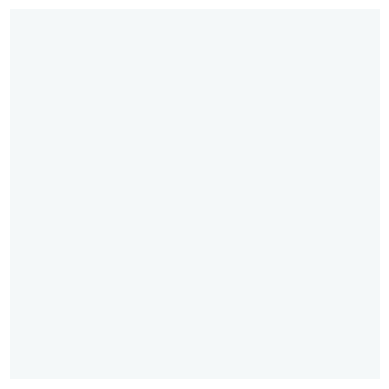

In [24]:
show_color(center[0])

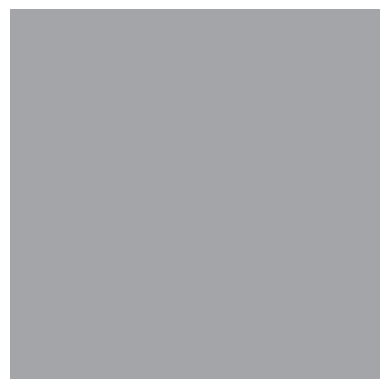

In [25]:
show_color(center[1])

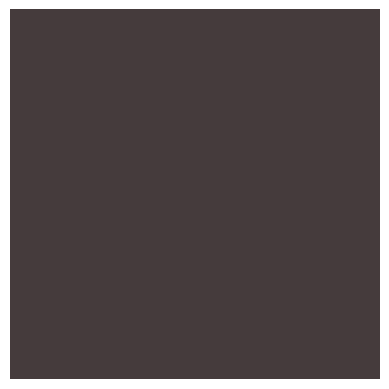

In [26]:
show_color(center[2])

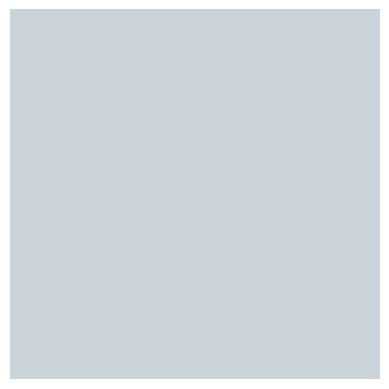

In [27]:
show_color(center[3])

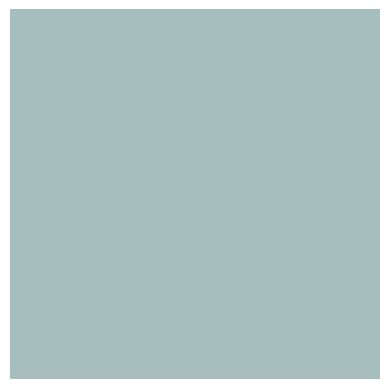

In [28]:
show_color(center[4])

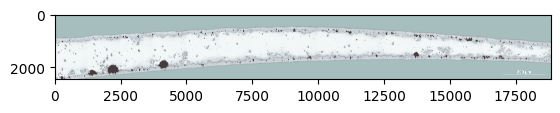

In [29]:
plt.imshow(res2, cmap = 'jet')